In [25]:
import json
import os
from pathlib import Path
import pathlib
import earthpy
import hvplot.xarray
import rioxarray as rxr
import xarray as xr
import osmnx as osm 
import geopandas as gpd
import hvplot.pandas 
import pandas as pd
import earthpy.api.appeears as eaapp



In [26]:
msu_denver_gdf = osm.features_from_address(
    "Metropolitan State University of Denver, Denver, CO, United States",
    {'amenity': ['university']},
    2000,
)
msu_denver_gdf

geometry  \
element id                                                               
node    2155391509                         POINT (-105.00774 39.74507)   
        5336796189                         POINT (-104.99685 39.74918)   
        12187139864                        POINT (-105.00461 39.74126)   
        12187139865                        POINT (-105.00177 39.74607)   
way     50807585     POLYGON ((-105.0016 39.74647, -105.00159 39.74...   

                    addr:city addr:housenumber addr:postcode addr:state  \
element id                                                                
node    2155391509     Denver              890         80204         CO   
        5336796189     Denver             1201         80202         CO   
        12187139864    Denver              800         80204         CO   
        12187139865    Denver             1201         80204         CO   
way     50807585       Denver             1201         80204         CO   

                         addr:street        alt_name     amenity designation  \
element id                                                                     
node    2155391509   Auraria Parkway      MSU Denver  university  University   
        5336796189       16th Street             NaN  university         NaN   
        12187139864    Curtis Street             NaN  university         NaN   
        12187139865   Larimer Street             NaN  university         NaN   
way     50807585          5th Street  Auraria Campus  university         NaN   

                                                        name  ...  \
element id                                                    ...   
node    2155391509   Metropolitan State University of Denver  ...   
        5336796189                 University of the Rockies  ...   
        12187139864              Community College of Denver  ...   
        12187139865            University of Colorado Denver  ...   
way     50807585             Auraria Higher Education Center  ...   

                                        website  wikidata addr:unit  \
element id                                                            
node    2155391509   https://www.msudenver.edu/   Q613736       NaN   
        5336796189                          NaN       NaN       200   
        12187139864        https://www.ccd.edu/       NaN       NaN   
        12187139865       https://ucdenver.edu/       NaN       NaN   
way     50807585     https://aurariacampus.edu/  Q4822139       NaN   

                    operator:type   ele gnis:feature_id internet_access  \
element id                                                                
node    2155391509            NaN   NaN             NaN             NaN   
        5336796189            NaN   NaN             NaN             NaN   
        12187139864        public   NaN             NaN             NaN   
        12187139865           NaN   NaN             NaN             NaN   
way     50807585              NaN  1584         2088849             yes   

                    internet_access:fee                          name:en  \
element id                                                                 
node    2155391509                  NaN                              NaN   
        5336796189                  NaN                              NaN   
        12187139864                 NaN                              NaN   
        12187139865                 NaN                              NaN   
way     50807585                     no  Auraria Higher Education Center   

                    wheelchair  
element id                      
node    2155391509         NaN  
        5336796189         NaN  
        12187139864        NaN  
        12187139865        NaN  
way     50807585       limited  

[5 rows x 23 columns]

<Axes: >

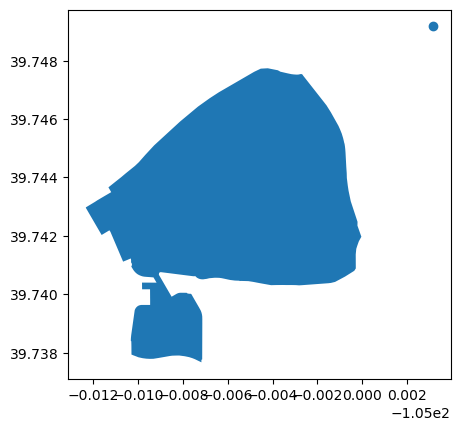

In [27]:
msu_denver_gdf.plot()

In [28]:

auraria = msu_denver_gdf[msu_denver_gdf.alt_name=="Auraria Campus"]

In [29]:
%store auraria

Stored 'auraria' (GeoDataFrame)


In [30]:
id = 'stars'
site_name = 'MSU Denver'
data_dir = 'msu-denver'
download_key = 'msu_ndvi'
project_title = 'MSU Denver Vegetation'
project = earthpy.Project(project_title, dirname=f"{data_dir}-vegetation")

In [31]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key=download_key,
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="06-01",
    end_date="09-01",
    recurring=True,
    year_range=[2015, 2025],
    polygon=auraria,
)

In [ ]:
ndvi_downloader.login(interactive=True, override=True)
ndvi_downloader.download_files(cache=False)


No stored credentials found for urs.earthdata.nasa.gov. Please log in.


/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:192: UserWarning: Setting credentials not supported for 'netrc' backend.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:196: UserWarning: Failed to store credentials with 'keyring': No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.
  warnings.warn(


Credentials stored using 'env' backend.
